C:\Users\cdoering\AppData\Local\Temp\ipykernel_20836\939234015.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


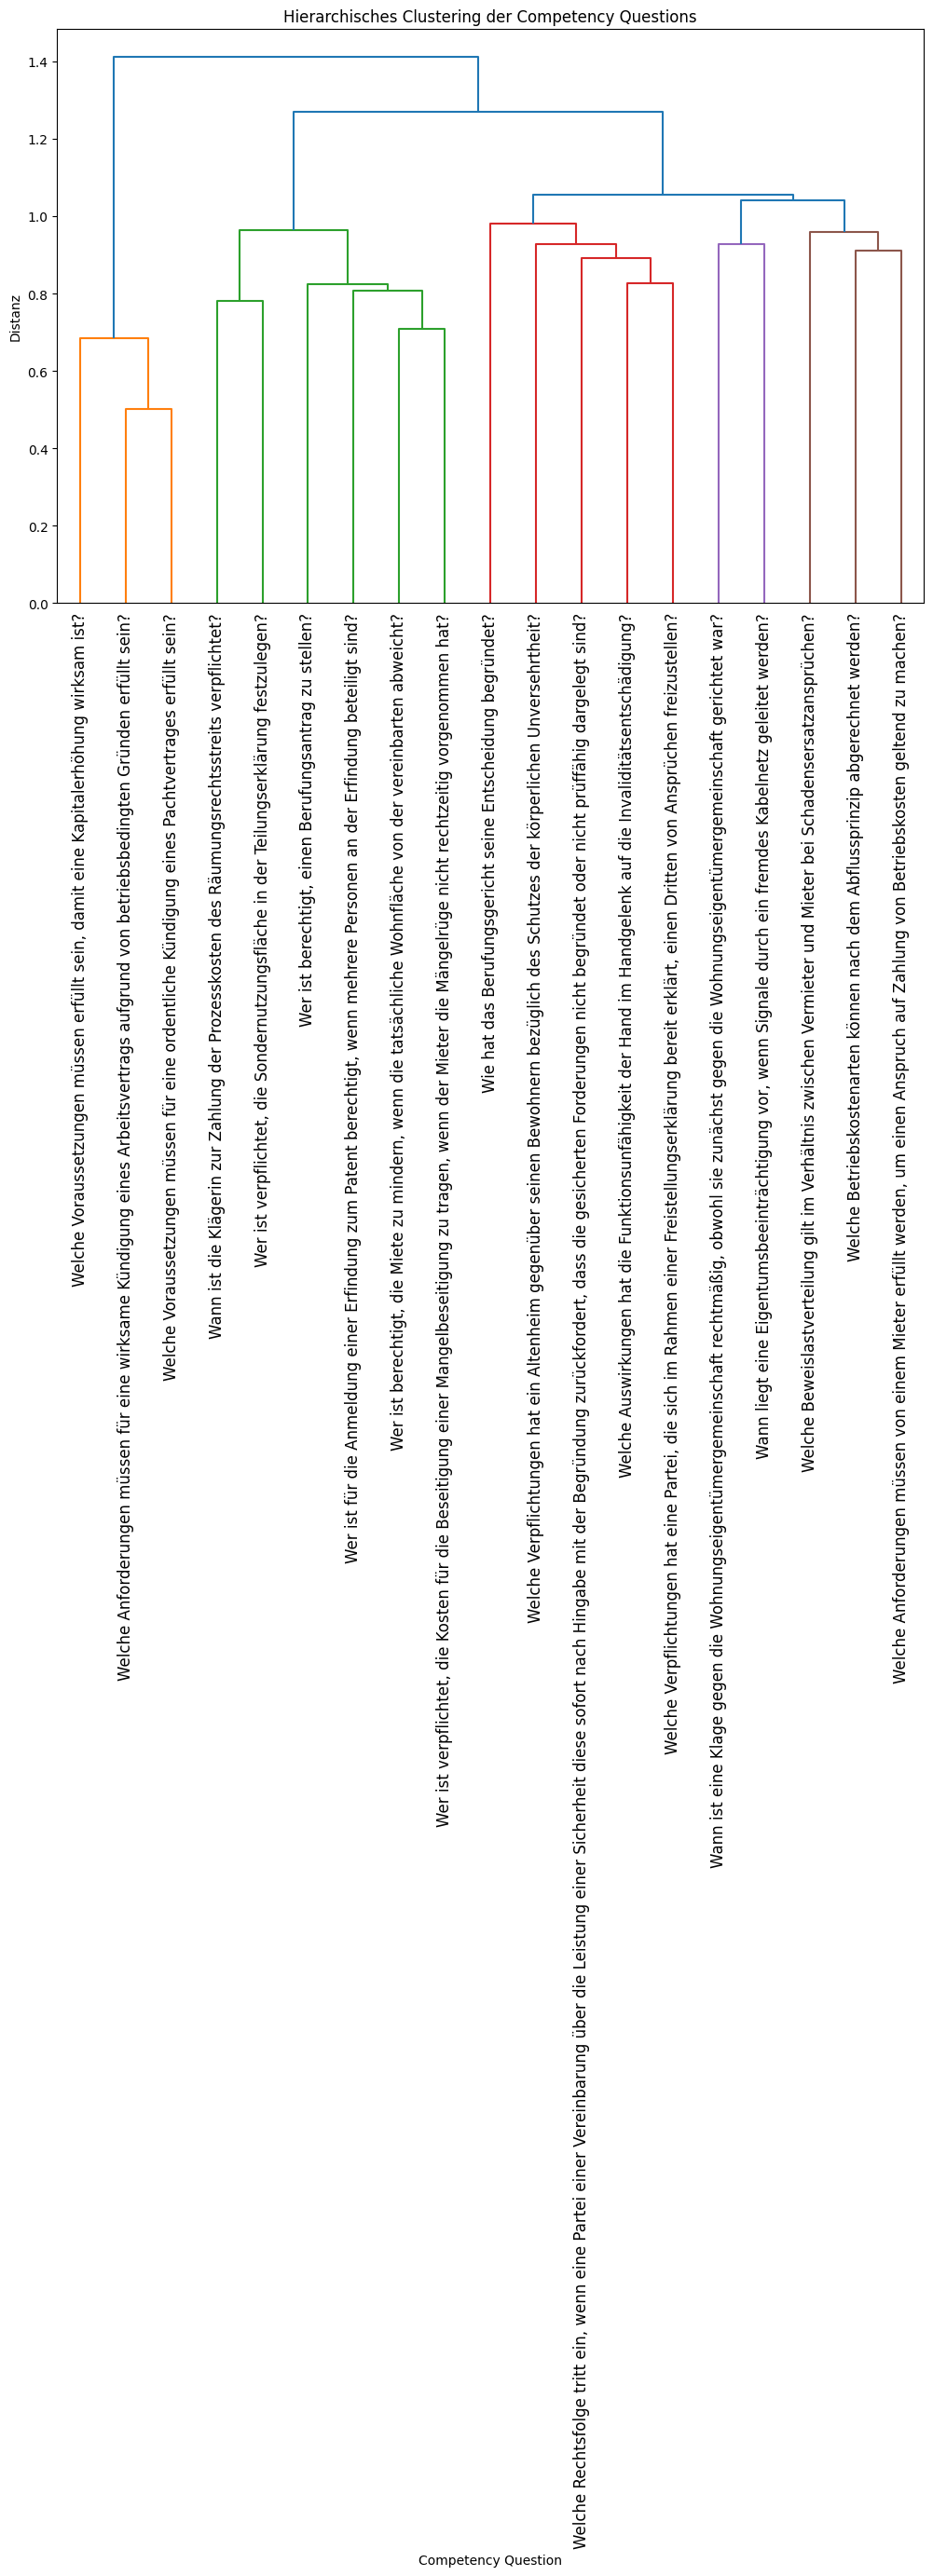

In [7]:
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram

# === Pfad zu deinen CQs ===
cq_path = r"C:\Users\cdoering\OneDrive - IW\Dokumente\Capstone\CapstoneDATEV25\competency_questions_output\competency_questions_all_documents.txt"

# === Competency Questions laden ===
with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

cq_blocks = re.split(r'Dokument:\s*', content)
questions = []

for block in cq_blocks[1:]:
    lines = block.strip().splitlines()
    frage_line = next((l for l in lines if l.lower().startswith("frage:")), None)
    if frage_line:
        question = frage_line.replace("Frage:", "").strip()
        questions.append(question)

# === TF-IDF-Vektorisierung ===
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

from scipy.spatial.distance import pdist, squareform

# Distanzen (kondensiert) korrekt berechnen
distances = pdist(X.toarray(), metric="cosine")

# Clustering
Z = linkage(distances, method="ward")


# === Dendrogramm anzeigen ===
plt.figure(figsize=(12, 8))
dendrogram(Z, labels=questions, leaf_rotation=90)
plt.title("Hierarchisches Clustering der Competency Questions")
plt.xlabel("Competency Question")
plt.ylabel("Distanz")
plt.tight_layout()
plt.show()
